# 01 — Ingestion Exploration

Purpose: sanity-check the two ingestion sources (yfinance prices, Google News RSS)
on a small sample of tickers before running the full 150-ticker production
ingestion (`src/ingestion/fetch_prices.py`, `src/ingestion/fetch_news.py`).

This notebook does NOT write to S3 by default in the price/news preview
cells -- it inspects raw responses first so you can confirm shapes/fields
match what `clean_transform.py` expects, then optionally runs the real
ingestion functions at the end.


In [1]:
import sys
from pathlib import Path

# so `from src.xxx import yyy` works when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import yfinance as yf
import requests
import os
from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")
pd.set_option("display.max_columns", None)

## 1. Load the master ticker list


In [2]:
tickers_df = pd.read_csv("../config/nifty150_midcap.csv")
print(f"{len(tickers_df)} tickers loaded")
tickers_df.head()

150 tickers loaded


,symbol
0,360ONE
1,3MINDIA
2,ACC
3,AIAENG
4,APLAPOLLO


In [3]:
# Sanity check -- an earlier version of this file was created empty via `touch`,
# and a later version had the wrong column name (NSE raw export uses "Symbol",
# not "symbol"). Both failures show up right here before anything else runs.
assert not tickers_df.empty, "nifty150_midcap.csv is empty -- populate it from the NSE index constituent list"
assert "symbol" in tickers_df.columns, f"Expected a symbol column, got: {tickers_df.columns.tolist()}"
assert len(tickers_df) == 150, f"Expected 150 tickers, got {len(tickers_df)} -- check for duplicates or a bad download"
print("Ticker list looks good:", len(tickers_df), "tickers")

Ticker list looks good: 150 tickers


## 2. Preview price data for a handful of tickers
Confirm the shape/columns match what `clean_transform.clean_prices()` expects
(`Date, Open, High, Low, Close, Volume` + a `ticker` column we add).

In [4]:
sample_tickers = tickers_df["symbol"].head(3).tolist()
sample_tickers = [f"{t}.NS" for t in sample_tickers]

price_frames = {}
for t in sample_tickers:
    df = yf.Ticker(t).history(period="5y", interval="1d")
    price_frames[t] = df
    print(t, df.shape)

price_frames[sample_tickers[0]].head()


360ONE.NS (1238, 7)
3MINDIA.NS (1237, 7)
ACC.NS (1239, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-07-27 00:00:00+05:30,290.042640,300.508944,282.787470,285.571167,100240,0.0,0.0
2021-07-28 00:00:00+05:30,286.919217,286.919217,277.000887,284.815002,240684,0.0,0.0
2021-07-29 00:00:00+05:30,284.946550,286.590473,279.466809,284.135559,103852,0.0,0.0
2021-07-30 00:00:00+05:30,284.288932,317.824943,284.288932,309.342316,919200,0.0,0.0
2021-08-02 00:00:00+05:30,317.583882,320.016881,310.032782,313.989166,238632,0.0,0.0


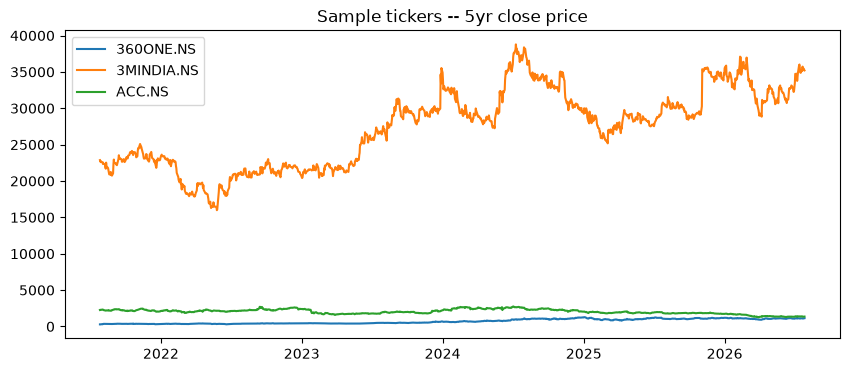

In [7]:
# Quick visual check -- close price over the 5y window
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
for t, df in price_frames.items():
    ax.plot(df.index, df["Close"], label=t)
ax.set_title("Sample tickers -- 5yr close price")
ax.legend()
plt.show()

## 3. Preview the Google News RSS response

Confirm the payload shape matches what `clean_transform.read_raw_news()`
expects: a `ticker` at the root and a `data` array of articles.

Note there is no `entities` array to resolve. marketaux was evaluated first
and rejected: it returned 8 articles across 100 Indian midcaps, and resolved
ticker symbols against a US-centric namespace, so a query for `ACC` returned
American Campus Communities (a US student-housing REIT) rather than ACC Ltd.
Those rows joined silently and would have fed a cement company's risk model
sentiment derived from American real estate news.

Google News is queried by *company name*, so the ticker association is made
at request time rather than resolution time — there is no symbol namespace
left to collide in.

In [ ]:
from src.ingestion.fetch_news import fetch_ticker_news, build_query
from urllib.parse import unquote

sample_symbol = tickers_df["symbol"].iloc[0]
sample_name = tickers_df["company_name"].iloc[0] if "company_name" in tickers_df.columns else sample_symbol

print("query:", unquote(build_query(sample_name, 30).split("q=")[1].split("&")[0]))
print()

payload = fetch_ticker_news(sample_symbol, sample_name, lookback_days=30, limit=5)
payload

In [ ]:
# Inspect the exact keys read downstream by read_raw_news()
print("Root keys:", list(payload.keys()))
print("Ticker (from the request, not resolved from content):", payload["ticker"])
print("Articles returned:", len(payload["data"]))

if payload["data"]:
    print("\nArticle keys:", list(payload["data"][0].keys()))
    for a in payload["data"][:5]:
        print(f'  [{a["published_at"][:10]}] {a["publisher"] or "?"}: {a["title"][:70]}')
else:
    print("\nNo articles -- check network access to news.google.com,")
    print("and that company_name is populated (scripts/enrich_ticker_names.py)")

## 4. Coverage check

Google News RSS needs no API key and imposes no published daily quota, so
there is no plan limit to check — the marketaux run was truncated at exactly
100 of 150 tickers by its free-tier ceiling.

What *is* worth checking is precision. Short acronym tickers (ACC, BSE, MRF,
SAIL, OIL) are the ones a name-based search can get wrong, so sample those
rather than a random selection. `scripts/check_news_quality.py` does this
across the awkward cases in one go.

In [ ]:
import time

# Precision spot-check on the ambiguous short-acronym tickers.
for sym in ["ACC", "BSE", "MRF"]:
    row = tickers_df[tickers_df["symbol"] == sym]
    if row.empty:
        continue
    name = row["company_name"].iloc[0] if "company_name" in row.columns else sym
    p = fetch_ticker_news(sym, name, lookback_days=30, limit=4)
    print(f"{sym} ({name}) -> {len(p['data'])} articles")
    for a in p["data"]:
        print(f"    {a['title'][:74]}")
    print()
    time.sleep(1.5)

## 5. Run the real ingestion (writes to S3)

Only run this once you're satisfied the shapes above look right --
this calls the production functions directly, so behavior here should
exactly match what the orchestrator triggers in production.


In [ ]:
from src.ingestion.fetch_prices import fetch_all_tickers_prices
from src.ingestion.fetch_news import fetch_all_tickers_news

# Uncomment when ready to actually populate S3:
# fetch_all_tickers_prices()
# fetch_all_tickers_news()